In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model =  ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

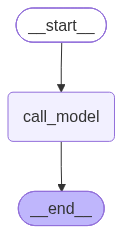

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Saurav."}]},
    config,
)

result["messages"][-1].content

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Current Token Count -> 10
Hi, my name is Saurav.


'Hi Saurav, nice to meet you! How can I help you today?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Saurav.
Hi Saurav, nice to meet you! How can I help you today?
I am learning LangGraph.


"That's fantastic, Saurav! LangGraph is an incredibly powerful library for building robust, stateful, and agentic applications with LLMs, especially for complex workflows.\n\nIt's a really rewarding library to learn once you get the hang of its graph-based approach.\n\nWhat stage are you at with your learning?\n*   Are you just getting started with the basics (nodes, edges, state)?\n*   Are you working on a specific project or use case (e.g., building an agent, a RAG system, a multi-agent setup)?\n*   Are you running into any particular challenges or have specific questions?\n\nLet me know how I can assist you!"

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a cognitive system that allows us to hold and process a limited amount of information for a brief period of time. Think of it as your brain\'s temporary "scratchpad" or "mental desktop" where you keep information you\'re actively using *right now*.\n\nHere are its key characteristics and functions:\n\n1.  **Limited Capacity:** This is one of its most defining features. STM can only hold a small amount of information at any given time. The classic research by George A. Miller (1956) suggested the "magical number seven, plus or minus two" items or "chunks" of information. For example, you can usually remember about 5-9 digits of a phone number, but not much more without special effort.\n    *   **Chunking:** We can overcome this limitation by "chunking" information – grouping individual pieces into larger, meaningful units. For instance, remembering "1492" as one historical date (Columbus sailed the ocean blue) is easier than remembering four separate digits (

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"As an AI, I don't know your name or any personal information about you. I don't have memory of past conversations or access to your identity."

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Saurav.
------------------------------------------------------------------------------------------------------------------------
Hi Saurav, nice to meet you! How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's fantastic, Saurav! LangGraph is an incredibly powerful library for building robust, stateful, and agentic applications with LLMs, especially for complex workflows.

It's a really rewarding library to learn once you get the hang of its graph-based approach.

What stage are you at with your learning?
*   Are you just getting started with the basics (nodes, edges, state)?
*   Are you working on a specific project or use case (e.g., building an agent, a RAG system, a multi-agent setup)?
*   Are you running into any particular